In [ ]:
!pip install seaborn

In [ ]:
import seaborn as sns

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
#Loading pre-defined Boston Dataset
boston_dataset = datasets.load_boston()
print(boston_dataset.DESCR)

ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

In [ ]:
# Generate scatter plot of independent vs Dependent variable
plt.style.use('ggplot')
fig = plt.figure(figsize = (18, 18))

for index, feature_name in enumerate(boston_dataset.feature_names):
	ax = fig.add_subplot(4, 4, index + 1)
	ax.scatter(boston_dataset.data[:, index], boston_dataset.target)
	ax.set_ylabel('House Price', size = 12)
	ax.set_xlabel(feature_name, size = 12)

plt.show()

NameError: name 'boston_dataset' is not defined

<Figure size 1800x1800 with 0 Axes>

In [ ]:
# Load the dataset into Pandas Dataframe
boston_pd = pd.DataFrame(boston_dataset.data)
boston_pd.columns = boston_dataset.feature_names
boston_pd_target = np.asarray(boston_dataset.target)
boston_pd['House Price'] = pd.Series(boston_pd_target)


# input
X = boston_pd.iloc[:, :-1]

#output
y = boston_pd.iloc[:, -1]

print(boston_pd.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  House Price  
0     15.3  396.90   4.98         24.0  
1     17.8  396.90   9.14         21.6  
2     17.8  392.83   4.03         34.7  
3     18.7  394.63   2.94         33.4  
4     18.7  396.90   5.33         36.2  


In [ ]:
boston_pd.rename(columns = {'House Price':'House_Price'}, inplace = True)

In [ ]:
boston_pd

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,House_Price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


In [ ]:
boston_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CRIM         506 non-null    float64
 1   ZN           506 non-null    float64
 2   INDUS        506 non-null    float64
 3   CHAS         506 non-null    float64
 4   NOX          506 non-null    float64
 5   RM           506 non-null    float64
 6   AGE          506 non-null    float64
 7   DIS          506 non-null    float64
 8   RAD          506 non-null    float64
 9   TAX          506 non-null    float64
 10  PTRATIO      506 non-null    float64
 11  B            506 non-null    float64
 12  LSTAT        506 non-null    float64
 13  House_Price  506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [ ]:
boston_pd.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,House_Price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


array([[<AxesSubplot:title={'center':'CRM'}>,
        <AxesSubplot:title={'center':'ZN'}>,
        <AxesSubplot:title={'center':'INDUS'}>,
        <AxesSubplot:title={'center':'CHAS'}>],
       [<AxesSubplot:title={'center':'NOX'}>,
        <AxesSubplot:title={'center':'RM'}>,
        <AxesSubplot:title={'center':'AGE'}>,
        <AxesSubplot:title={'center':'DIS'}>],
       [<AxesSubplot:title={'center':'RAD'}>,
        <AxesSubplot:title={'center':'TAX'}>,
        <AxesSubplot:title={'center':'PTRATIO'}>,
        <AxesSubplot:title={'center':'B'}>],
       [<AxesSubplot:title={'center':'LSTAT'}>,
        <AxesSubplot:title={'center':'MEDV'}>, <AxesSubplot:>,
        <AxesSubplot:>]], dtype=object)

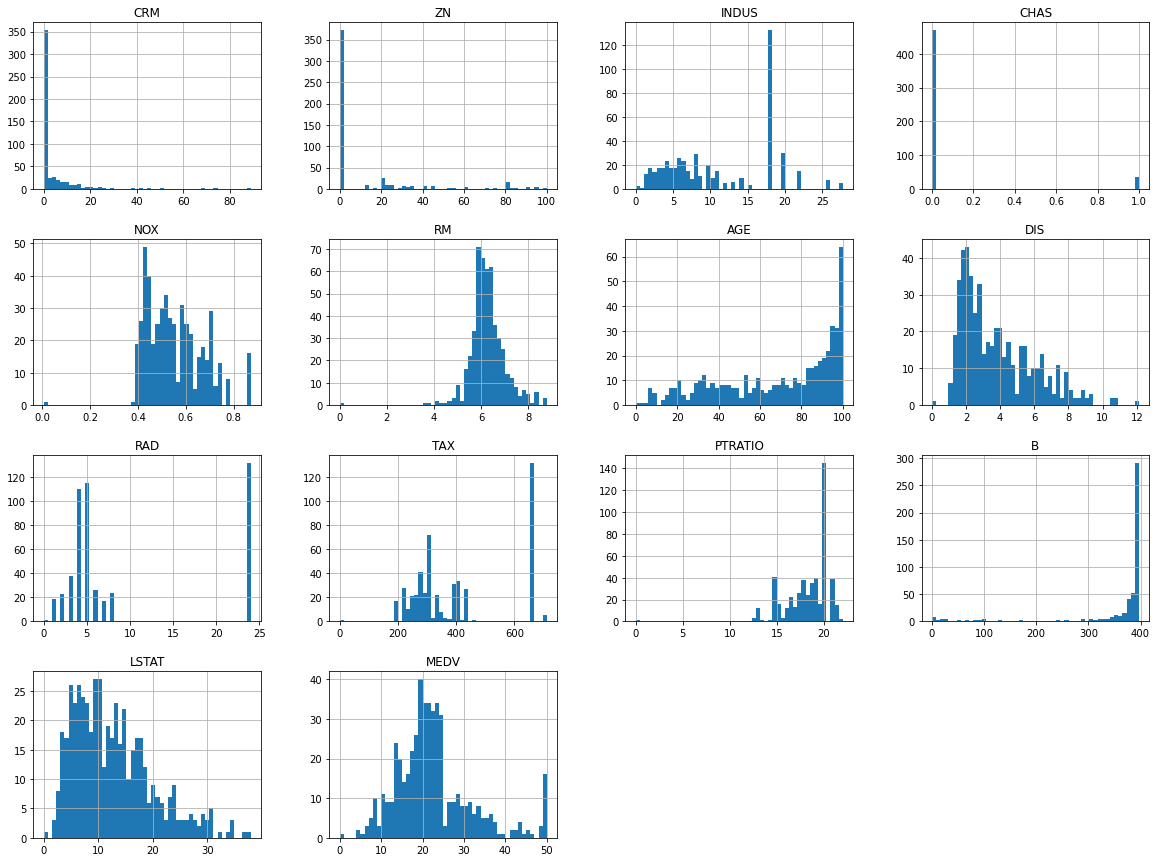

In [ ]:
housing.hist(bins=50, figsize=(20, 15))

# TRAIN AND TES DATASET

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
	boston_pd.iloc[:, :-1], boston_pd.iloc[:, -1],
	test_size = 0.25)

print("Train data shape of X = % s and Y = % s : "%(
	x_train.shape, y_train.shape))

print("Test data shape of X = % s and Y = % s : "%(
	x_test.shape, y_test.shape))

Train data shape of X = (379, 13) and Y = (379,) : 
Test data shape of X = (127, 13) and Y = (127,) : 


# Multiple (Linear) Regression
plt.tight_layout()

In [ ]:
# Apply multiple Linear Regression Model
lreg = LinearRegression()
lreg.fit(x_train, y_train)

# Generate Prediction on test set
lreg_y_pred = lreg.predict(x_test)

# calculating Mean Squared Error (mse)
mean_squared_error = np.mean((lreg_y_pred - y_test)**2)
print("Mean squared Error on test set : ", mean_squared_error)

# Putting together the coefficient and their corresponding variable names
lreg_coefficient = pd.DataFrame()
lreg_coefficient["Columns"] = x_train.columns
lreg_coefficient['Coefficient Estimate'] = pd.Series(lreg.coef_)
print(lreg_coefficient)

Mean squared Error on test set :  27.101045667228217
    Columns  Coefficient Estimate
0      CRIM             -0.116172
1        ZN              0.054637
2     INDUS             -0.001410
3      CHAS              2.273746
4       NOX            -19.944056
5        RM              3.834670
6       AGE             -0.004823
7       DIS             -1.776868
8       RAD              0.329603
9       TAX             -0.012186
10  PTRATIO             -0.940092
11        B              0.008569
12    LSTAT             -0.479933


cm =
np.correof(data.values.T)
sns.set(font_scale=1.5)
hm = sns.heatmap(cm,
                 cbar=True,
                 annot=True,
                 square=True,
                 fmt='.2f',
                 annot_kws=
 {'size': 15},
 yticklable=cols,
 xticklabels=cols)
                 

# Splitting the data into training data and testing data
                 

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=23)
print(X.shape,X_train.shape,X_test.shape)

(506, 13) (354, 13) (152, 13)


In [ ]:
# Step 1: add x0 =1 to dataset
X_train_0 = np.c_[np.ones((X_train.shape[0],1)),X_train]
X_test_0 = np.c_[np.ones((X_test.shape[0],1)),X_test]

# Step2: build model
theta = np.matmul(np.linalg.inv( np.matmul(X_train_0.T,X_train_0) ), np.matmul(X_train_0.T,y_train))

In [ ]:
#The parameters for linear regression model
parameter = ['theta_'+str(i) for i in range(X_train_0.shape[1])]
columns = ['intersect:x_0=1'] + list(X.columns.values)
parameter_df = pd.DataFrame({'Parameter':parameter,'Columns':columns,'theta':theta})

In [ ]:
# Scikit Learn module
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train) # Note: x_0 =1 is no need to add, sklearn will take care of it.

#Parameter
sk_theta = [lin_reg.intercept_]+list(lin_reg.coef_)
parameter_df = parameter_df.join(pd.Series(sk_theta, name='Sklearn_theta'))
parameter_df

,Parameter,Columns,theta,Sklearn_theta
0,theta_0,intersect:x_0=1,27.789607,27.789607
1,theta_1,CRIM,-0.093418,-0.093418
2,theta_2,ZN,0.043303,0.043303
3,theta_3,INDUS,-0.022522,-0.022522
4,theta_4,CHAS,3.342047,3.342047
5,theta_5,NOX,-16.330196,-16.330196
6,theta_6,RM,4.271930,4.271930
7,theta_7,AGE,0.000721,0.000721
8,theta_8,DIS,-1.403231,-1.403231
9,theta_9,RAD,0.255429,0.255429


In [ ]:
from sklearn.linear_model import LinearRegression   ## importing the model library

LR=LinearRegression()  ## importing the model object
LR.fit(X_train,y_train) ## fitting the training data

X_test_pred=LR.predict(X_test)

In [ ]:
X_test_pred

array([25.48882634, 26.85383326, 26.50113697, 16.8311552 , 38.90548232,
       15.92640789, 19.23152198, 29.28806615, 33.79428877, 38.25894258,
       16.19079976, 27.79685578, 25.35181876, 25.61234607, 21.35214307,
       19.1221877 , 31.34939126, 31.18316962, 29.08034579, 28.90724661,
       19.59636559, 17.90783181, 24.98877865, 24.00154542, 13.56628155,
       22.08791583, 32.99232593, 28.36965015, 29.65108026, 39.94060342,
       18.66689308, 14.92285788, 19.6923896 , 19.20029267, 20.14718966,
       37.91700834, 24.21072339, 30.86942899, 13.24009483, 36.42525089,
        8.97985188, 13.88836303, 11.78208526, 19.61208754, 36.32061974,
       20.01573887, 11.5591671 , 21.66102362, 13.54102458, 39.34825195,
       22.51984897,  2.71613802, 17.75797283, 18.44448789, 24.04115464,
       32.92544769,  5.97982079, 21.7327963 , 17.46853879, 22.60218768,
       17.64957037, 21.74406196, 21.65178897, 43.91766166, 30.82382874,
       29.34034013, 21.19730767, 16.86447485, 31.17198257, 13.38

In [ ]:
y_test

176    23.2
311    22.1
94     20.6
139    17.8
232    41.7
       ... 
213    28.1
373    13.8
437     8.7
281    35.4
263    31.0
Name: House Price, Length: 152, dtype: float64

In [ ]:
X_train_pred=LR.predict(X_train)

X_train_pred

array([28.01461138, 36.80216616, 23.70952129, 25.33238798, 14.58713451,
        4.02831675, 16.46964961, 15.31109056, 24.46348312, 19.86827983,
       21.20733862, 21.02551979, 14.23243986, 11.01209312, 28.75588999,
        7.81919285, 25.79608254, 23.49908773, 11.63393429, 34.0170896 ,
       17.05566551, 27.34319041, 26.87326117, 17.35822354, 19.37238392,
       25.39219424, 32.21718937, 26.26119746, 17.51759856, 23.51568418,
       11.42812914, 21.91770534, 21.45374728, 28.02188599, 28.34693427,
       26.48070923, 20.90232834, 22.69199685,  8.89806003, 21.824246  ,
       35.17532263, 24.20971653, 24.88900457, 25.70286413, 28.36671058,
       11.06643436, 28.17656467, 24.17745944, 19.34322413, 42.02777239,
       19.46805125, 20.68112329, 20.84432164, 17.11643776, 37.23989864,
       18.57049292, 24.00951791, 35.74073997, 24.86055626, 18.93177957,
       14.6104225 , 26.97638569, 20.09168866, 28.77204391, 22.4687519 ,
       32.61747803, 18.64840947, 23.41481114, 19.95795005, 23.20

# Polynomial Linear regression(Plot the best fit line)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
poly_features = PolynomialFeatures(2)

In [ ]:
X_train_poly = poly_features.fit_transform(X_train)
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

LinearRegression()

In [ ]:
from sklearn import metrics
y_test_predict = poly_model.predict(poly_features.fit_transform(X_test))
rmse_test = np.sqrt(metrics.mean_squared_error(y_test, y_test_predict))
r2_test = r2_score(y_test, y_test_predict)

In [ ]:
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_predict)))

RMSE: 6.928385682276273


In [ ]:
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_predict)))

RMSE: 6.928385682276273


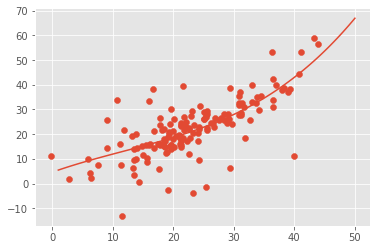

In [ ]:
import matplotlib.pyplot as plt


mymodel = np.poly1d(np.polyfit(X_test_pred, y_test_predict, 3))

myline = np.linspace(1, 50, 100)

plt.scatter(X_test_pred, y_test_predict)
plt.plot(myline, mymodel(myline))
plt.show()

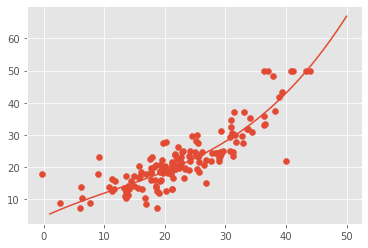

In [ ]:
mymodel = np.poly1d(np.polyfit(X_test_pred, y_test_predict, 3))

myline = np.linspace(1, 50, 100)

plt.scatter(X_test_pred, y_test)
plt.plot(myline, mymodel(myline))
plt.show()

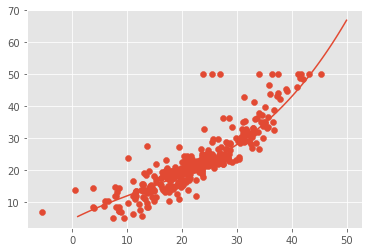

In [ ]:
mymodel = np.poly1d(np.polyfit(X_test_pred, y_test_predict, 3))

myline = np.linspace(1, 50, 100)

plt.scatter(X_train_pred, y_train)
plt.plot(myline, mymodel(myline))
plt.show()

# Check for Homoscedasticity


In [ ]:
residuals = y_train.values-X_train_pred
mean_residuals = np.mean(residuals)
print("Mean of Residuals {}".format(mean_residuals))

Mean of Residuals 3.574792690363668e-14


In [ ]:
esiduals = y_test.values-X_test_pred
mean_residuals = np.mean(residuals)
print("Mean of Residuals {}".format(mean_residuals))

Mean of Residuals 3.574792690363668e-14


In [ ]:
residuals = y_test.values-X_test_pred
mean_residuals = np.mean(residuals)
print("Mean of Residuals {}".format(mean_residuals))

Mean of Residuals -0.42498300493017743


# Check for Normality of error terms/residuals

C:\Users\DELL\AppData\Local\Temp\ipykernel_5612\3040778317.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p = sns.distplot(residuals,kde=True)


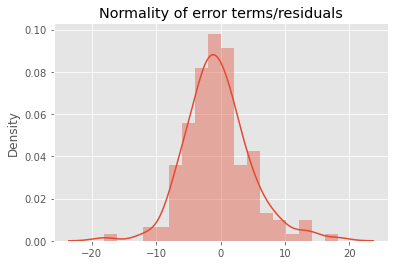

In [ ]:
p = sns.distplot(residuals,kde=True)
p = plt.title('Normality of error terms/residuals')

# No perfect multicollinearity¶


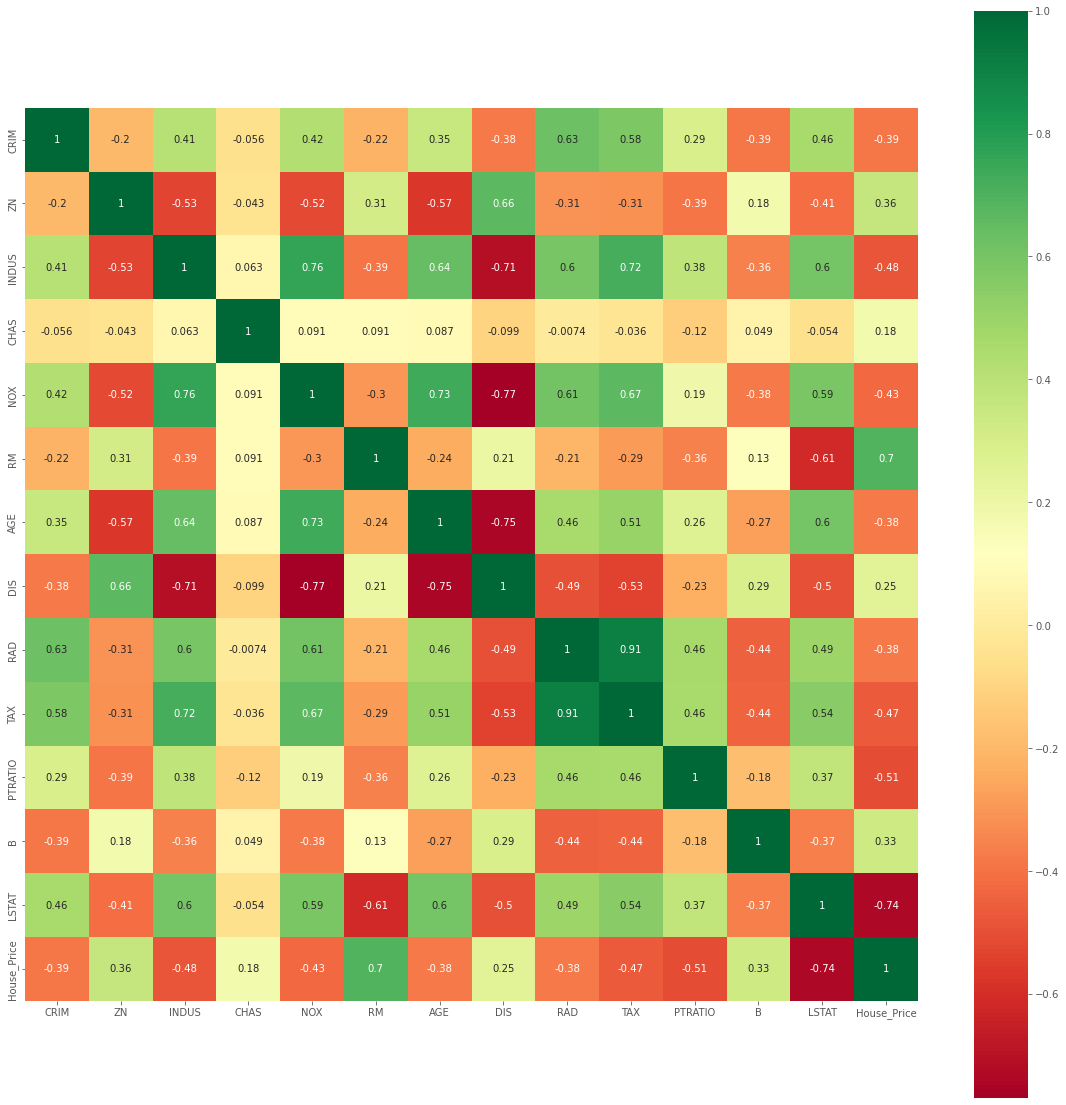

In [ ]:
plt.figure(figsize=(20,20))  # on this line I just set the size of figure to 12 by 10.
p=sns.heatmap(boston_pd.corr(), annot=True,cmap='RdYlGn',square=True)  # seaborn has very simple solution for heatmap

# Some other model evaluations

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dec_tree = DecisionTreeRegressor(random_state=0)
dec_tree.fit(X_train,y_train)
dec_tree_y_pred = dec_tree.predict(X_train)
print("Accuracy: {}".format(dec_tree.score(X_train,y_train)))
print("R squared: {}".format(r2_score(y_true=y_train,y_pred=dec_tree_y_pred)))

Accuracy: 1.0
R squared: 1.0


In [ ]:
dec_tree = DecisionTreeRegressor(random_state=0)
dec_tree.fit(X_train,y_train)
dec_tree_y_pred = dec_tree.predict(X_test)
print("Accuracy: {}".format(dec_tree.score(X_test,y_test)))
print("R squared: {}".format(r2_score(y_true=y_test,y_pred=dec_tree_y_pred)))

Accuracy: 0.7917359657247152
R squared: 0.7917359657247152


In [ ]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train,y_train)
svr_y_pred = svr.predict(X_train)
print("Accuracy: {}".format(svr.score(X_train,y_train)))
print("R squared: {}".format(r2_score(y_true=y_train,y_pred=svr_y_pred)))

Accuracy: 0.2096313266695523
R squared: 0.2096313266695523


# SVM (SUPPORT VECTOR MACHINE)

In [ ]:
# Creating scaled set to be used in model to improve our results
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
# Import SVM Regressor
from sklearn import svm

# Create a SVM Regressor
reg = svm.SVR()

In [ ]:
# Train the model using the training sets
reg.fit(X_train, y_train)

SVR()

In [ ]:
# Model prediction on train data
y_pred = reg.predict(X_train)

In [ ]:
# Model Evaluation
print('R^2:',metrics.r2_score(y_train, y_pred))
print('Adjusted R^2:',1 - (1-metrics.r2_score(y_train, y_pred))*(len(y_train)-1)/(len(y_train)-X_train.shape[1]-1))
print('MAE:',metrics.mean_absolute_error(y_train, y_pred))
print('MSE:',metrics.mean_squared_error(y_train, y_pred))
print('RMSE:',np.sqrt(metrics.mean_squared_error(y_train, y_pred)))

R^2: 0.6485661974193706
Adjusted R^2: 0.6351290226148172
MAE: 2.9617291351732637
MSE: 29.86768372661503
RMSE: 5.465133459176915


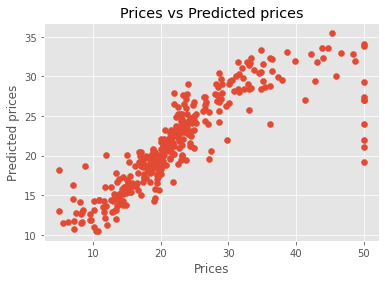

In [ ]:
# Visualizing the differences between actual prices and predicted values
plt.scatter(y_train, y_pred)
plt.xlabel("Prices")
plt.ylabel("Predicted prices")
plt.title("Prices vs Predicted prices")
plt.show()


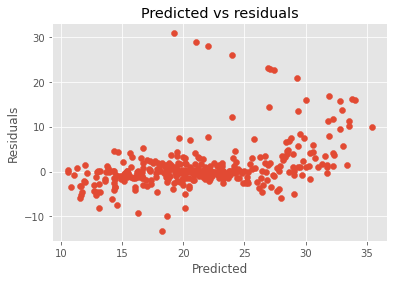

In [ ]:
# Checking residuals
plt.scatter(y_pred,y_train-y_pred)
plt.title("Predicted vs residuals")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

In [ ]:
# Predicting Test data with the model
y_test_pred = reg.predict(X_test)

In [ ]:
#Model Evaluation
acc_svm = metrics.r2_score(y_test, y_test_pred)
print('R^2:', acc_svm)
print('Adjusted R^2:',1 - (1-metrics.r2_score(y_test, y_test_pred))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print('MAE:',metrics.mean_absolute_error(y_test, y_test_pred))
print('MSE:',metrics.mean_squared_error(y_test, y_test_pred))
print('RMSE:',np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

R^2: 0.6505868792198586
Adjusted R^2: 0.6176711504507149
MAE: 3.361681864389094
MSE: 29.032094818396697
RMSE: 5.388143912183183


# KNN K-Nearest Value

In [ ]:
import IPython
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib
import sklearn as sk


In [ ]:
from sklearn.datasets import load_boston
bdata = load_boston()

C:\Users\DELL\anaconda3\envs\orange3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function load_boston is deprecated; `load_boston` is deprecated in 1.0 and will be removed in 1.2.

    The Boston housing prices dataset has an ethical problem. You can refer to
    the documentation of this function for further details.

    The scikit-learn maintainers therefore strongly discourage the use of this
    dataset unless the purpose of the code is to study and educate about
    ethical issues in data science and machine learning.

    In this special case, you can fetch the dataset from the original
    source::

        import pandas as pd
        import numpy as np

        data_url = "http://lib.stat.cmu.edu/datasets/boston"
        raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
        data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
        target = raw_df.values[1::2, 2]

    Alternative datasets include the California housin

In [ ]:
# uncomment the following if you want to see a lengthy description of the dataset
print(bdata.keys())
print(bdata.feature_names)
print(bdata.data.shape)
print(bdata.target.shape)
print(bdata.DESCR)

dict_keys(['data', 'target', 'feature_names', 'DESCR', 'filename', 'data_module'])
['CRIM' 'ZN' 'INDUS' 'CHAS' 'NOX' 'RM' 'AGE' 'DIS' 'RAD' 'TAX' 'PTRATIO'
 'B' 'LSTAT']
(506, 13)
(506,)
.. _boston_dataset:

Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted

# Histogram of housing prices


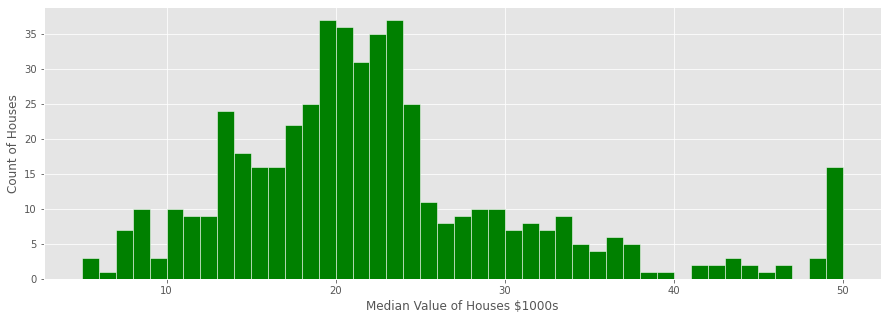

In [ ]:
# prepare IPython to work with matplotlib and import the library to something convenient
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# edit the code below to make the graph look good
plt.figure(figsize=(15,5))
plot = plt.hist(bdata.target, bins=45, color='g', edgecolor = 'white')
plt.xlabel('Median Value of Houses $1000s')
plt.ylabel('Count of Houses')
plt.show()

# Scatter plot of housing prices and crime

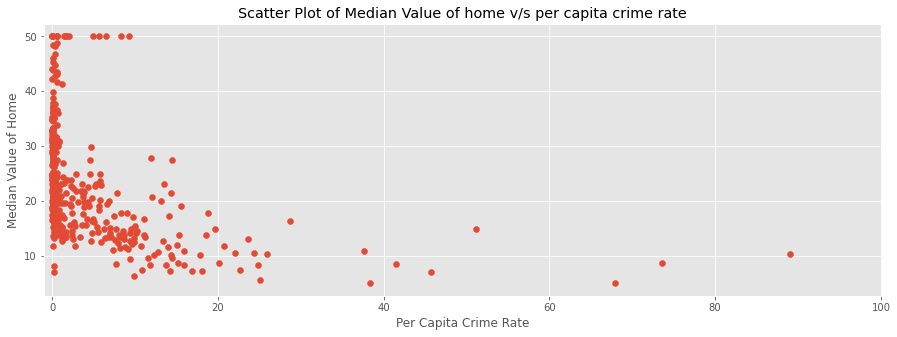

In [ ]:
plt.figure(figsize=(15,5))
plot = plt.scatter(bdata.data[:,0], bdata.target)
plt.xlim(-1,100)
plt.ylabel('Median Value of Home')
plt.xlabel('Per Capita Crime Rate')
plt.title('Scatter Plot of Median Value of home v/s per capita crime rate')
plt.show()


In [ ]:
# built in datasets and other required functions are imported from
# sklearn
from sklearn import datasets
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import math
#Loading the Boston dataset
boston=datasets.load_boston()
x=boston.data[:,:]
y=boston.target
print(x.shape,y.shape)
tsize=0.30 #30% of total data is used for testing and 70% used for training
## splitting the dataset into training and testing sets,
# (parameter random state is fixed at some integer, to ensure the
# same train and test sets across various runs)
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=tsize,random_state=102)

(506, 13) (506,)


C:\Users\DELL\anaconda3\envs\orange3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function load_boston is deprecated; `load_boston` is deprecated in 1.0 and will be removed in 1.2.

    The Boston housing prices dataset has an ethical problem. You can refer to
    the documentation of this function for further details.

    The scikit-learn maintainers therefore strongly discourage the use of this
    dataset unless the purpose of the code is to study and educate about
    ethical issues in data science and machine learning.

    In this special case, you can fetch the dataset from the original
    source::

        import pandas as pd
        import numpy as np

        data_url = "http://lib.stat.cmu.edu/datasets/boston"
        raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
        data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
        target = raw_df.values[1::2, 2]

    Alternative datasets include the California housin

In [ ]:
## Exploring the dataset characteristics and having glimpse of data
# printing the sizes of training and testing data sets
print(xtrain.shape,ytrain.shape)
print(xtest.shape,ytest.shape)
# Print the information contained within the dataset
print("\nKeys of iris_dataset: \n{}".format(boston.keys()))
print(boston['DESCR'][:500] + "\n...")
#Print the feature names
print("\nFeature names: \n{}".format(boston['feature_names']))
#Printing the  Few Rows
print("\nFirst five rows of data:\n{}".format(boston['data'][:5]))
#Print the class values few datapoints
print("\nTarget:\n{}".format(boston['target'][:5]))
#Print the dimensions of data
print("\nShape of data: {}".format(boston['data'].shape))

(354, 13) (354,)
(152, 13) (152,)

Keys of iris_dataset: 
dict_keys(['data', 'target', 'feature_names', 'DESCR', 'filename', 'data_module'])
.. _boston_dataset:

Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
   
...

Feature names: 
['CRIM' 'ZN' 'INDUS' 'CHAS' 'NOX' 'RM' 'AGE' 'DIS' 'RAD' 'TAX' 'PTRATIO'
 'B' 'LSTAT']

First five rows of data:
[[6.3200e-03 1.8000e+01 2.3100e+00 0.0000e+00 5.3800e-01 6.5750e+00
  6.5200e+01 4.0900e+00 1.0000e+00 2.9600e+02 1.5300e+01 3.9690e+02
  4.9800e+00]
 [2.7310e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 6.4210e+00
  7.89

In [ ]:
##function to find Euclidean distance
def edist(v1,v2):
    return np.sqrt(np.sum((v1-v2)**2))
##function to predict values using knn for given test data tx
def knn_reg(tr_x, tr_y, tx , k):

    distances = []

    #Find distances between new data and all the training data
    for i in range(tr_x.shape[0]):
        distances.append(edist(tr_x[i], tx))

    #sort the distances in ascending order
    distances = np.array(distances)
    inds = np.argsort(distances)

    distances = distances[inds]
    tr_y_sorted = tr_y[inds] #sorted values of target variable

    #predicted value is the average of first k values of target
    #vector
    value = np.average(tr_y_sorted[:k])
    return value

In [ ]:
##Function to find mean squared error for the entire test dataset
def knn_mse(tr_x , tr_y, test_x , test_y , k):
    preds = []
    for i in range(test_x.shape[0]):
        value = knn_reg(tr_x, tr_y, test_x[i] , k)
        preds.append(value)

    preds  = np.array(preds)
    err = mean_squared_error(test_y , preds)
    return err

In [ ]:
##Finding MSEs for different values of k
maxk=int(math.sqrt(xtrain.shape[0])) #maximum value of k
mse_val = [] #to store rmse values for different k
for k in range(1,maxk):
    error= knn_mse(xtrain , ytrain , xtest , ytest ,k)
    mse_val.append(error) #store rmse values
    print('MSE value for k= ' , k , 'is:', error)

MSE value for k=  1 is: 52.069736842105264
MSE value for k=  2 is: 41.056726973684206
MSE value for k=  3 is: 42.38861842105264
MSE value for k=  4 is: 44.16745065789473
MSE value for k=  5 is: 40.99719736842106
MSE value for k=  6 is: 39.929205043859646
MSE value for k=  7 is: 40.511697099892594
MSE value for k=  8 is: 38.973344983552636
MSE value for k=  9 is: 38.55725064977258
MSE value for k=  10 is: 38.853878289473684
MSE value for k=  11 is: 38.987844715093516
MSE value for k=  12 is: 40.50879797149122
MSE value for k=  13 is: 41.166428682653375
MSE value for k=  14 is: 43.0698419038668
MSE value for k=  15 is: 44.86796023391812
MSE value for k=  16 is: 46.46832879317434
MSE value for k=  17 is: 47.82060599162265


Best Value of k using elbow curve is 


NameError: name 'ke' is not defined

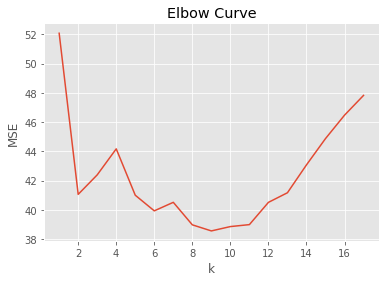

In [ ]:
##plotting the elbow curve
k=np.arange(1,maxk)
xl="k"
yl="MSE"
plt.xlabel(xl)
plt.ylabel(yl)
plt.title("Elbow Curve")
plt.plot(k,mse_val)
##finding the k for the elbow point
print("Best Value of k using elbow curve is ")
plt.plot(ke,mse_val[ke-1],'rx')
plt.annotate("  elbow point", (ke,mse_val[ke-1]))

In [ ]:
#Now model is ready to predict the cost for new house with given features in xnew vector and ke as k
x = np.array([2.7310e-02, 0.0000e+00, 7.0700e+00, 0.0000e+00, \ 4.6900e-01, 6.4210e+00, 7.8900e+01, 4.9671e+00, 2.0000e+00, \ 2.4200e+02, 1.7800e+01, 3.9690e+02 ,9.1400e+00])
hcost=knn_reg(xtrain, ytrain, xnew , ke)
print("Predicted price of the given house is {:.2f}".format(hcost),\ "thousand dollars")

SyntaxError: unexpected character after line continuation character (3651661439.py, line 2)